<a href="https://colab.research.google.com/github/AJasa1983/Assessment_Repo/blob/main/programmng_for_Data_Analysis_st20350980.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the Environment
#importing Libraries and Connect to Github

In [2]:
# ── IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# Set a consistent visual style for all matplotlib/seaborn charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# ── GITHUB SETUP ─────────────────────────────────────────────────────────
# Configure Git identity — this is required so Git knows who is making commits
! git config --global user.name "AJasa1983"
! git config --global user.email "ofemomini60@gmail.com"

# Store your GitHub credentials
username = "AJasa1983"
repo     = "Assessment_Repo"

# Clone the repository if it hasn't been cloned yet in this session
# The '-f' flag in 'test -d' checks whether the folder already exists
import os
if not os.path.exists(repo):
    os.system(f'git clone https://github.com/{username}/{repo}')
    print(f'Cloned {repo} successfully.')
else:
    print(f'{repo} already exists — skipping clone.')

# Move into the repository folder so all file operations happen there
%cd {repo}
print('Working directory:', os.getcwd())

Cloned Assessment_Repo successfully.
/content/Assessment_Repo
Working directory: /content/Assessment_Repo


Merging the csv files

In [4]:
# LOAD & MERGE DATA
# ──────────────────────────────────────
# glob.glob finds all CSV files in the current directory
city_files = glob.glob('*.csv')
print(f'CSV files found: {city_files}')

# Read each file into a list, then concatenate into one DataFrame
all_data = []
for f in city_files:
    temp = pd.read_csv(f)
    all_data.append(temp)
    print(f'  Loaded {f} — {len(temp):,} rows')

# pd.concat stacks all DataFrames on top of each other (row-wise)
# ignore_index=True resets the index to be continuous 0, 1, 2 ...
df = pd.concat(all_data, ignore_index=True)

print(f'\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

CSV files found: ['PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv']
  Loaded PRSA_Data_Huairou_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Shunyi_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Tiantan_20130301-20170228.csv — 35,064 rows
  Loaded PRSA_Data_Dongsi_20130301-20170228.csv — 35,064 rows

Merged dataset: 140,256 rows x 18 columns


DATA UNERSTANDING

Before any Analysis, we need to understand what the Datasets looks like.
1. How many Eows and columns does it have?
2. What are the Data types of each column?
3. Are there any missing values we need to handle?
4. Statistical details about the ranges and distribution

In [5]:
# ── SHAPE & COLUMNS ────────────────────────────────────────────────

print('=' * 55)
print(f'  Total Rows    : {df.shape[0]:,}')
print(f'  Total Columns : {df.shape[1]}')
print('=' * 55)

# List of all column names so we know what variables are available
print('\nColumn Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

  Total Rows    : 140,256
  Total Columns : 18

Column Names:
   1. No
   2. year
   3. month
   4. day
   5. hour
   6. PM2.5
   7. PM10
   8. SO2
   9. NO2
  10. CO
  11. O3
  12. TEMP
  13. PRES
  14. DEWP
  15. RAIN
  16. wd
  17. WSPM
  18. station


In [11]:
# DATA TYPES ─────────────────────────────────────────────────────
# the types tells us how pandas has interpreted each column.
# the 'int64' and 'float64' are numeric columns.
# the 'object' usually means text or string (like station name or wind direction).

print('Column Data Types:')
print(df.dtypes)

print('\nFirst 15 rows of data:')
display(df.head(15))

Column Data Types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

First 15 rows of data:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou
5,6,2013,3,1,5,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
6,7,2013,3,1,6,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
7,8,2013,3,1,7,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
8,9,2013,3,1,8,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
9,10,2013,3,1,9,17.0,36.0,50.0,28.0,700.0,60.0,-1.1,1025.4,-23.8,0.0,NE,4.9,Huairou


Columns with Missing Values:


,Missing Count,Missing %
CO,7923,5.65
NO2,5349,3.81
O3,4147,2.96
SO2,4057,2.89
PM2.5,3293,2.35
PM10,2475,1.76
wd,941,0.67
TEMP,142,0.10
PRES,144,0.10
DEWP,147,0.10


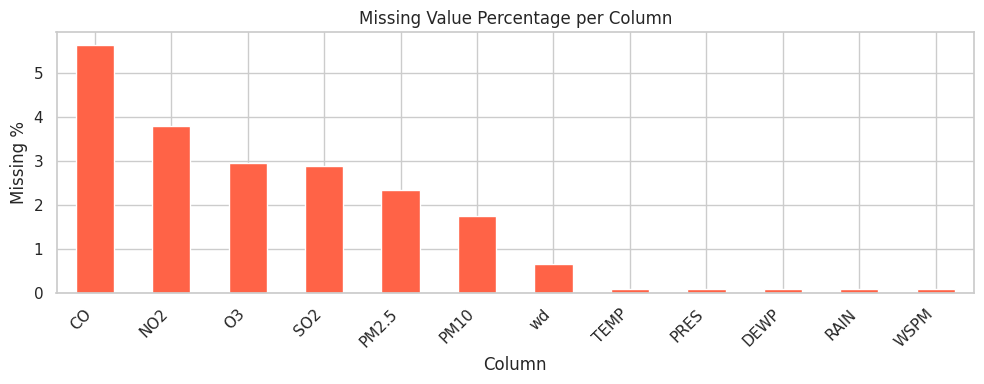

In [12]:
# ──MISSING VALUES ─────────────────────────────────────────────────
# isnull().sum() counts how many NaN (Not a Number) values are in each column.
# We also calculate the percentage.

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
})

# Only show columns that actually have missing values
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with Missing Values:')
display(missing_report)

# Visualise missing values as a bar chart for easier interpretation
missing_report['Missing %'].plot(
    kind='bar', figsize=(10, 4), color='tomato', edgecolor='white'
)
plt.title('Missing Value Percentage per Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

OBSERVATIONS

* The combined Dataset has 140,256 hourly records across 4 stations between (2013 - 2017)
* Each station contributes 35,064 rows - the data is evenly distributed
* Pollutant columns (pm2.5, pm10, SO2, NO2, CO, 03) and metrological column (TEMP, PRES, DEWP, RAIN, WSPM) have varying amount of missing data.
* PM2.5 values have a high maximum, suggesting pluution spikes (outlier)
* Year ranges from 2013 - 2017; hour ranges from 0 to 23- hourly resolution
* The 'WD' column (Wind direction) is categoricaly (text), all others are numeric

In [ ]:
# STATISTICAL SUMMARY ────────────────────────────────────────────
# describe() shows count, mean, std deviation, min, max, and quartiles
# for every numeric column. This helps spot outliers and understand ranges.

print('Statistical Summary of Numeric Columns:')
display(df.describe().round(2))

# How many records does each station have?
print('\nRecord Count per Station:')
print(df['station'].value_counts())

Statistical Summary of Numeric Columns:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.00,140256.00,140256.00,140256.00,140256.00,136963.00,137781.00,136199.00,134907.00,132333.00,136109.00,140114.00,140112.00,140109.00,140110.00,140135.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.39,101.75,14.66,45.86,1208.21,57.06,13.29,1011.44,2.40,0.06,1.80
std,10122.14,1.18,3.45,8.80,6.92,80.42,90.54,20.58,32.15,1115.95,56.72,11.55,10.42,13.85,0.80,1.27
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.80,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,34.00,2.00,21.00,500.00,12.00,3.00,1003.00,-9.00,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,80.00,6.00,39.00,900.00,45.00,14.30,1011.00,3.00,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,141.00,18.00,64.00,1500.00,81.00,23.10,1019.70,15.10,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,941.00,999.00,315.00,258.00,10000.00,1071.00,41.10,1042.80,29.10,46.40,12.90



Record Count per Station:
station
Huairou    35064
Shunyi     35064
Tiantan    35064
Dongsi     35064
Name: count, dtype: int64
